In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('data/processed/train.csv', index_col = 0)
test = pd.read_csv('data/processed/test.csv', index_col = 0)


In [2]:
X_train = train[['Adult weight (g)']]
y_train = train['Maximum longevity (yrs)']

X_test = test[['Adult weight (g)']]
y_test = test['Maximum longevity (yrs)']

X_train_log = np.log10(X_train)
y_train_log = np.log10(y_train)
X_test_log = np.log10(X_test)
y_test_log = np.log10(y_test)


In [3]:
import os
os.makedirs('figures', exist_ok = True)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', HuberRegressor())
])

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pipe.fit(X_train_log, y_train_log)
y_pred_train = pipe.predict(X_train_log)

scaler = pipe.named_steps['scaler']
model = pipe.named_steps['model']

slope = model.coef_[0]/scaler.scale_[0]
intercept = model.intercept_ - (model.coef_[0] * scaler.mean_[0]/ scaler.scale_[0])
mae_train = mean_absolute_error(y_train_log, y_pred_train)

print(f'Slope: {slope:.3f}')
print(f'Intercept: {intercept:.3f}')
print(f'Train set R² score: {r2_score(y_train_log, y_pred_train):.3f}')
print(f'Train set MAE: {mae_train:.3f}')
print(f'Train predictions lie within a factor of {10**mae_train:.2f} of true values')


Slope: 0.159
Intercept: 0.661
Train set R² score: 0.473
Train set MAE: 0.179
Train predictions lie within a factor of 1.51 of true values


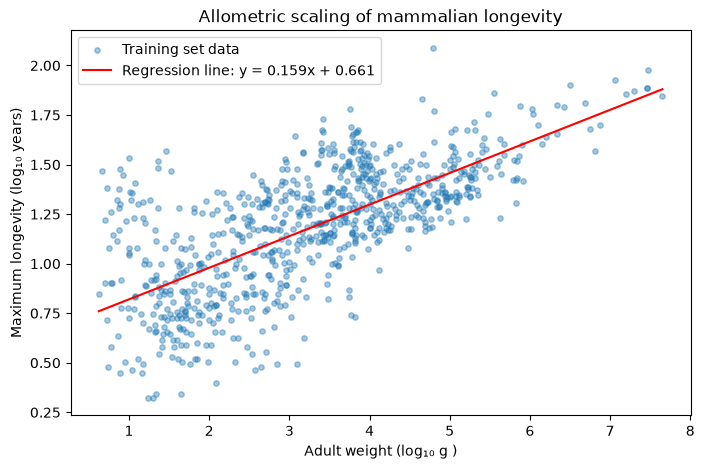

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x = X_train_log.values.ravel()
y = y_train_log.values

x_line = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(8,5))
plt.scatter(x, y , alpha = 0.4, s = 15, label = 'Training set data' )
plt.plot(x_line, slope* x_line + intercept, color = 'red',label=f'Regression line: y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('Adult weight (log₁₀ g )')
plt.ylabel('Maximum longevity (log₁₀ years)')
plt.title('Allometric scaling of mammalian longevity')
plt.legend()
plt.savefig('figures/huber_regression.png', dpi = 150)
plt.show()


In [7]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits = 10, shuffle = True, random_state = 42)

r2_scores = cross_val_score(pipe, X_train_log, y_train_log, cv= cv, scoring = 'r2')
mae_scores = cross_val_score(pipe, X_train_log, y_train_log, cv= cv, scoring = 'neg_mean_absolute_error')

print(f'R² Score per fold: {r2_scores}')
print()
print(f'MAE per fold: {-mae_scores}')
print()
print(f'CV Predictions lie within a factor of {10**-mae_scores.mean():.2f} of true values')



R² Score per fold: [0.42614337 0.37939133 0.53363286 0.34366469 0.5907562  0.48778685
 0.46209576 0.45541615 0.4269581  0.51875703]

MAE per fold: [0.19700635 0.19610006 0.16706258 0.17184841 0.16263005 0.17828737
 0.16614841 0.19096871 0.19308    0.16917348]

CV Predictions lie within a factor of 1.51 of true values


In [8]:
raw_residuals = y_train_log.values - y_pred_train

scale = model.scale_

standardized_residuals = raw_residuals / scale

train_residuals = train.copy()

train_residuals['standardized_residuals'] = standardized_residuals

order_summary = train_residuals.groupby('Order')['standardized_residuals'].agg(['mean', 'std', 'count']).sort_values('mean', ascending = False)

print(order_summary)


                     mean       std  count
Order                                     
Chiroptera       2.021163  1.410822     77
Monotremata      1.809782  0.652382      2
Primates         1.738999  0.715003    119
Pilosa           1.356190  0.992085      4
Sirenia          1.191795  1.340829      2
Proboscidea      0.984096  0.555723      2
Cingulata        0.444588  1.363810      6
Scandentia       0.327822  0.444956      4
Perissodactyla   0.294022  0.624661     12
Cetacea          0.209284  0.839756     29
Carnivora        0.128128  0.800733    125
Afrosoricida     0.021111  1.481984      4
Macroscelidea   -0.114743  0.362025      4
Diprotodontia   -0.355543  1.109912     42
Hyracoidea      -0.466318  0.114959      2
Artiodactyla    -0.678283  0.567555    114
Rodentia        -0.822018  1.217080    183
Lagomorpha      -0.929844  0.470072      9
Erinaceomorpha  -1.298422  0.506591      6
Dasyuromorphia  -1.534511  0.821197     20
Didelphimorphia -2.392544  1.362538     12
Peramelemor

In [9]:
train_residuals[train_residuals['Order'] == 'Rodentia'][['Order','Genus', 'Species', 'Common name', 'standardized_residuals']].sort_values('standardized_residuals', ascending = False).head(10)

,Order,Genus,Species,Common name,standardized_residuals
2822,Rodentia,Cryptomys,anselli,Ansell's mole-rat,2.304940
3114,Rodentia,Glaucomys,volans,Southern flying squirrel,2.217135
3177,Rodentia,Spalax,ehrenbergi,Palestine mole rat,1.979004
3142,Rodentia,Sciurus,carolinensis,Eastern gray squirrel,1.873069
3101,Rodentia,Callosciurus,prevostii,Prevost's squirrel,1.679071
3098,Rodentia,Callosciurus,erythraeus,Pallas's squirrel,1.226231
3127,Rodentia,Petaurista,alborufus,Red and white giant flying squirrel,1.045187
2988,Rodentia,Hystrix,brachyura,Malayan porcupine,1.035576
2985,Rodentia,Atherurus,africanus,African brush-tailed porcupine,1.019152
3100,Rodentia,Callosciurus,notatus,Plantain squirrel,0.987757


In [10]:
train_residuals_final = y_train_log.values - y_pred_train
train['residual'] = train_residuals_final

In [11]:
np.corrcoef(train['residual'], np.log10(train['Adult weight (g)']))[0,1]


np.float64(-0.02780269747408601)

In [12]:
y_pred_test = pipe.predict(X_test_log)

mae_test = mean_absolute_error(y_test_log, y_pred_test)

print(f'Test set R² score: {r2_score(y_test_log, y_pred_test):.3f}')
print(f'Test set MAE: {mae_test:.3f}')
print(f'Test predictions lie within a factor of {10**mae_test:.2f} of true values')



Test set R² score: 0.565
Test set MAE: 0.183
Test predictions lie within a factor of 1.52 of true values


In [13]:
test_residuals_final = y_test_log.values - y_pred_test
test['residual'] = test_residuals_final

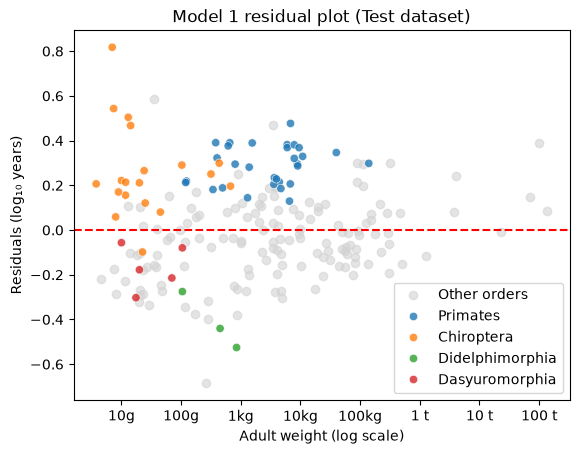

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

residual_plot = test.copy()
residual_plot['log_weight'] = X_test_log.values.ravel()

highlight = ['Chiroptera', 'Primates', 'Dasyuromorphia', 'Didelphimorphia']
others = residual_plot[~residual_plot['Order'].isin(highlight)]
focus = residual_plot[residual_plot['Order'].isin(highlight)]

plt.scatter(others['log_weight'], others['residual'], color = 'lightgrey', alpha = 0.6, label = 'Other orders')
sns.scatterplot(data = focus, x = 'log_weight', y = 'residual', hue = 'Order', alpha = 0.8)
plt.axhline(0, color = 'red', linestyle = '--')

plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], ['10g', '100g', '1kg', '10kg', '100kg', '1 t', '10 t', '100 t'])
plt.xlabel('Adult weight (log scale)')
plt.ylabel('Residuals (log₁₀ years)')
plt.title('Model 1 residual plot (Test dataset)')
plt.legend()
plt.savefig('figures/residual_plot.png', dpi = 150)
plt.show()

In [15]:
import joblib

import os
os.makedirs('data/interim', exist_ok = True)

train.to_csv('data/interim/train_residuals.csv')
test.to_csv('data/interim/test_residuals.csv')
joblib.dump(pipe, 'model1_pipe.pkl')

['model1_pipe.pkl']